# RGC Morphometry

In [1]:
import sys
sys.path.append('/home/jovyan/projects/cellcount/')
import os
print(os.getcwd())
os.chdir('/home/jovyan/projects/cellcount')
print(os.getcwd())
import pandas as pd
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
#import matplotlib.image as mpimg
%matplotlib inline
from skimage import io
from skimage import measure
from skimage import color
from PIL import Image

from read_roi import read_roi_zip

from utils import *

from shapely.geometry import Polygon, MultiPolygon, GeometryCollection
from shapely.validation import explain_validity, make_valid

/home/jovyan
/home/jovyan/projects/cellcount


In [2]:
# path2kdrive = "/home/jovyan/kDrive/cellcount"
# path2retines = os.path.join(path2kdrive, "data/retines")
# list_of_roifiles = [
# "Hr11/Hr11_Ft_25_3_RGC_RoiSet.zip",
# "Hr11/Hr11_Fc_18_2_1_RGC_RoiSet.zip",
# "Aa06/Aa06_Ft_27_2_1_RGC_RoiSet.zip",
# "Aa06/Aa06-NRc_7-2_4_GCL.zip"
# ]
# ratio = [1763.21/5652, 1468.41/4707, 2055.21/6588, 305.26/1957] # ratio microns/px
#path2image = os.path.join(path2retines, "Hr11-Fovea_central_18_2-1-overview-Stitching-01.czi #1.tif")
#path2roiset = os.path.join(path2retines, "Hr11_Ft_25_3_RGC_RoiSet.zip")

In [3]:
path2kdrive = "/home/jovyan/kDrive"
path2retines = os.path.join(path2kdrive, "tania/NR_cell_count")
roifiles = {
    "Aa06_temporal": "Aa06/Aa06_Ft/Aa06_Ft_27_2_2_RGC_RoiSet.zip",
    "Aa06_central": "Aa06/Aa06_NRc/Aa06-NRc_7-2_4_RGC.zip",
    "Ag27_central": "Ag27/Ag27Fc/Ag27_Fc_26_1_1_RGC_RoiSet.zip",
    "Ag27_temporal": "Ag27/Ag27NRt/Ag27_Ft_10_3_1_RGC_RoiSet.zip",
    "An01_central": "An01/An01_Fc/An01_Fc_36_1_3_GCL_RoiSet.zip",
    "An01_temporal": "An01/An01_NRt/An01_Ft_29_2_5_GCL_RoiSet.zip",
    "Cj22_central": "Cj22/Cj22_NRc/Cj22_NRc_6_3_2_RGC_RoiSet.zip",
    "Cj22_temporal": "Cj22/Cj22_NRt/Cj22_NRt_3_4_2_RGC_RoiSet.zip",
    "ClDP_central": "Cl_PV_10W/Fc/Cl_PV_Fc_10W_27_2_2_RGC_RoiSet.zip",
    "ClDP_temporal": "Cl_PV_10W/NRt_Red_field/Cl_PV_Red_10W_5_1_2_RGC_RoiSet.zip",
    "Du25_central": "Du25/Du25_Fc/Du25_Fc_29_4_1_RGC_RoiSet.zip",
    "Du25_temporal": "Du25/Du25_Ft/Du25_Ft_19_2_1_RGC_RoiSet.zip",
    "Ft03_central": "Ft03/Ft03_Fc/Ft03_Fc_28_3_6_RGC_RoiSet.zip",
    "Ft03_temporal": "Ft03/Ft03_Ft/Ft03_Ft_35_1_2_RGC_RoiSet.zip",
    "GgP48_central": "GgP48/GgP48NRc/GgP48_NRc_9_4_2_RGC_RoiSet.zip",
    "GgP48_temporal": "GgP48/GgP48NRt/GgP48_NR3_2_2_1_RGC_RoiSet.zip",
    "Hr11_central": "Hr11/Hr11_Fc/Hr11_Fc_18_2_2_RGC_RoiSet.zip",
    "Hr11_temporal": "Hr11/Hr11_Ft/Hr11_Ft_25_3_1_RGC_40x_RoiSet.zip",
    "Mc12_central": "Mc12/Mc12_Fc/Mc12_FovC_17_2_2_RGC_RoiSet.zip",
    "Mc12_temporal": "Mc12/Mc12_NRt/Mc12_NRt_8_3_4_RGC_RoiSet.zip",
    "Mm04_central": "Mm04/Mm04_Fc/Mm04_Fc_54bis_2_2_RGC_RoiSet.zip",
    "Mm04_temporal": "Mm04/Mm04_NRt/Mm04_NRt_26_4_2_RGC_RoiSet.zip",
    "Sa20_central": "Sa20/Sa20_NRc/Sa20_NRc_24_3_3_RGC_RoiSet.zip",
    "Sa20_temporal": "Sa20/Sa20_NRt/Sa20_NRt_NR1_1_1_4_RGC_RoiSet.zip"
}
print("number of files : " + str(len(roifiles)))
# ratio microns/px :
ratio = {
    "Aa06_temporal": 734.2/4707,
    "Aa06_central": 305.26/1957,
    "Ag27_central": 3807.2/24408,
    "Ag27_temporal": 2669.15/17112,
    "An01_central": 735.61/4716,
    "An01_temporal": 379.51/3832,
    "Cj22_central": 2665.41/17088,
    "Cj22_temporal": 1447.51/9280,
    "ClDP_central": 3309.3/21216,
    "ClDP_temporal": 2822.64/18096,
    "Du25_central": 1806.89/11584,
    "Du25_temporal": 932.15/5976,
    "Ft03_central": 381.49/3852,
    "Ft03_temporal": 602.24/3861,
    "GgP48_central": 875.99/5616,
    "GgP48_temporal": 4035.55/25872,
    "Hr11_central": 734.2/4707,
    "Hr11_temporal": 731.4/4689,
    "Mc12_central": 735.61/4716,
    "Mc12_temporal": 423.02/2712,
    "Mm04_central": 1309.78/8397,
    "Mm04_temporal": 456.25/2925,
    "Sa20_central": 448.13/2873,
    "Sa20_temporal": 448.6/2876
}
#print(ratio)

number of files : 24


Extract polygons from roi files and compute area in $\mu m^2$ : 

In [4]:
polygon_dict = {}
area_dict = {}
for k, v in roifiles.items():
    #print(k)
    path2roiset = os.path.join(path2retines, v)
    # import rois from zip file:
    rois = read_roi_zip(path2roiset)
    # convert rois to shapely.Polygon objects:
    polygon_list = []
    for r in rois:
        poly = (r, contour2polygon(np.column_stack((rois[r]['x'], rois[r]['y']))))
        polygon_list.append(poly)
    # sort in-place polygons from  largest to smallest: 
    #polygon_list.sort(key=lambda x: x[1].area, reverse=True)
    polygon_dict[k] = polygon_list
    areas = [polygon_list[i][1].area * ratio[k] ** 2 for i in range(len(polygon_list))]
    area_dict[k] = areas
#area_dict

Plot histograms:

Aa06_temporal ('min area :', 19.43959188203531, 'max area :', 190.8680829969549)
Aa06_central ('min area :', 21.216543562735758, 'max area :', 130.26763100331107)
Ag27_central ('min area :', 14.208879834896777, 'max area :', 97.86852591758952)
Ag27_temporal ('min area :', 22.44454435890348, 'max area :', 163.6809454466376)
An01_central ('min area :', 9.683463684515422, 'max area :', 85.05876643483899)
An01_temporal ('min area :', 11.299205991082674, 'max area :', 106.98935672806408)
Cj22_central ('min area :', 13.357276597430511, 'max area :', 114.92367214565213)
Cj22_temporal ('min area :', 17.87059419907302, 'max area :', 122.5881400572218)
ClDP_central ('min area :', 14.695426798661728, 'max area :', 134.4728872784824)
ClDP_temporal ('min area :', 11.33787657444997, 'max area :', 163.85178066659512)
Du25_central ('min area :', 11.08242273901644, 'max area :', 134.8989964357336)
Du25_temporal ('min area :', 21.751436763200722, 'max area :', 234.4970330243049)
Ft03_central ('min area 

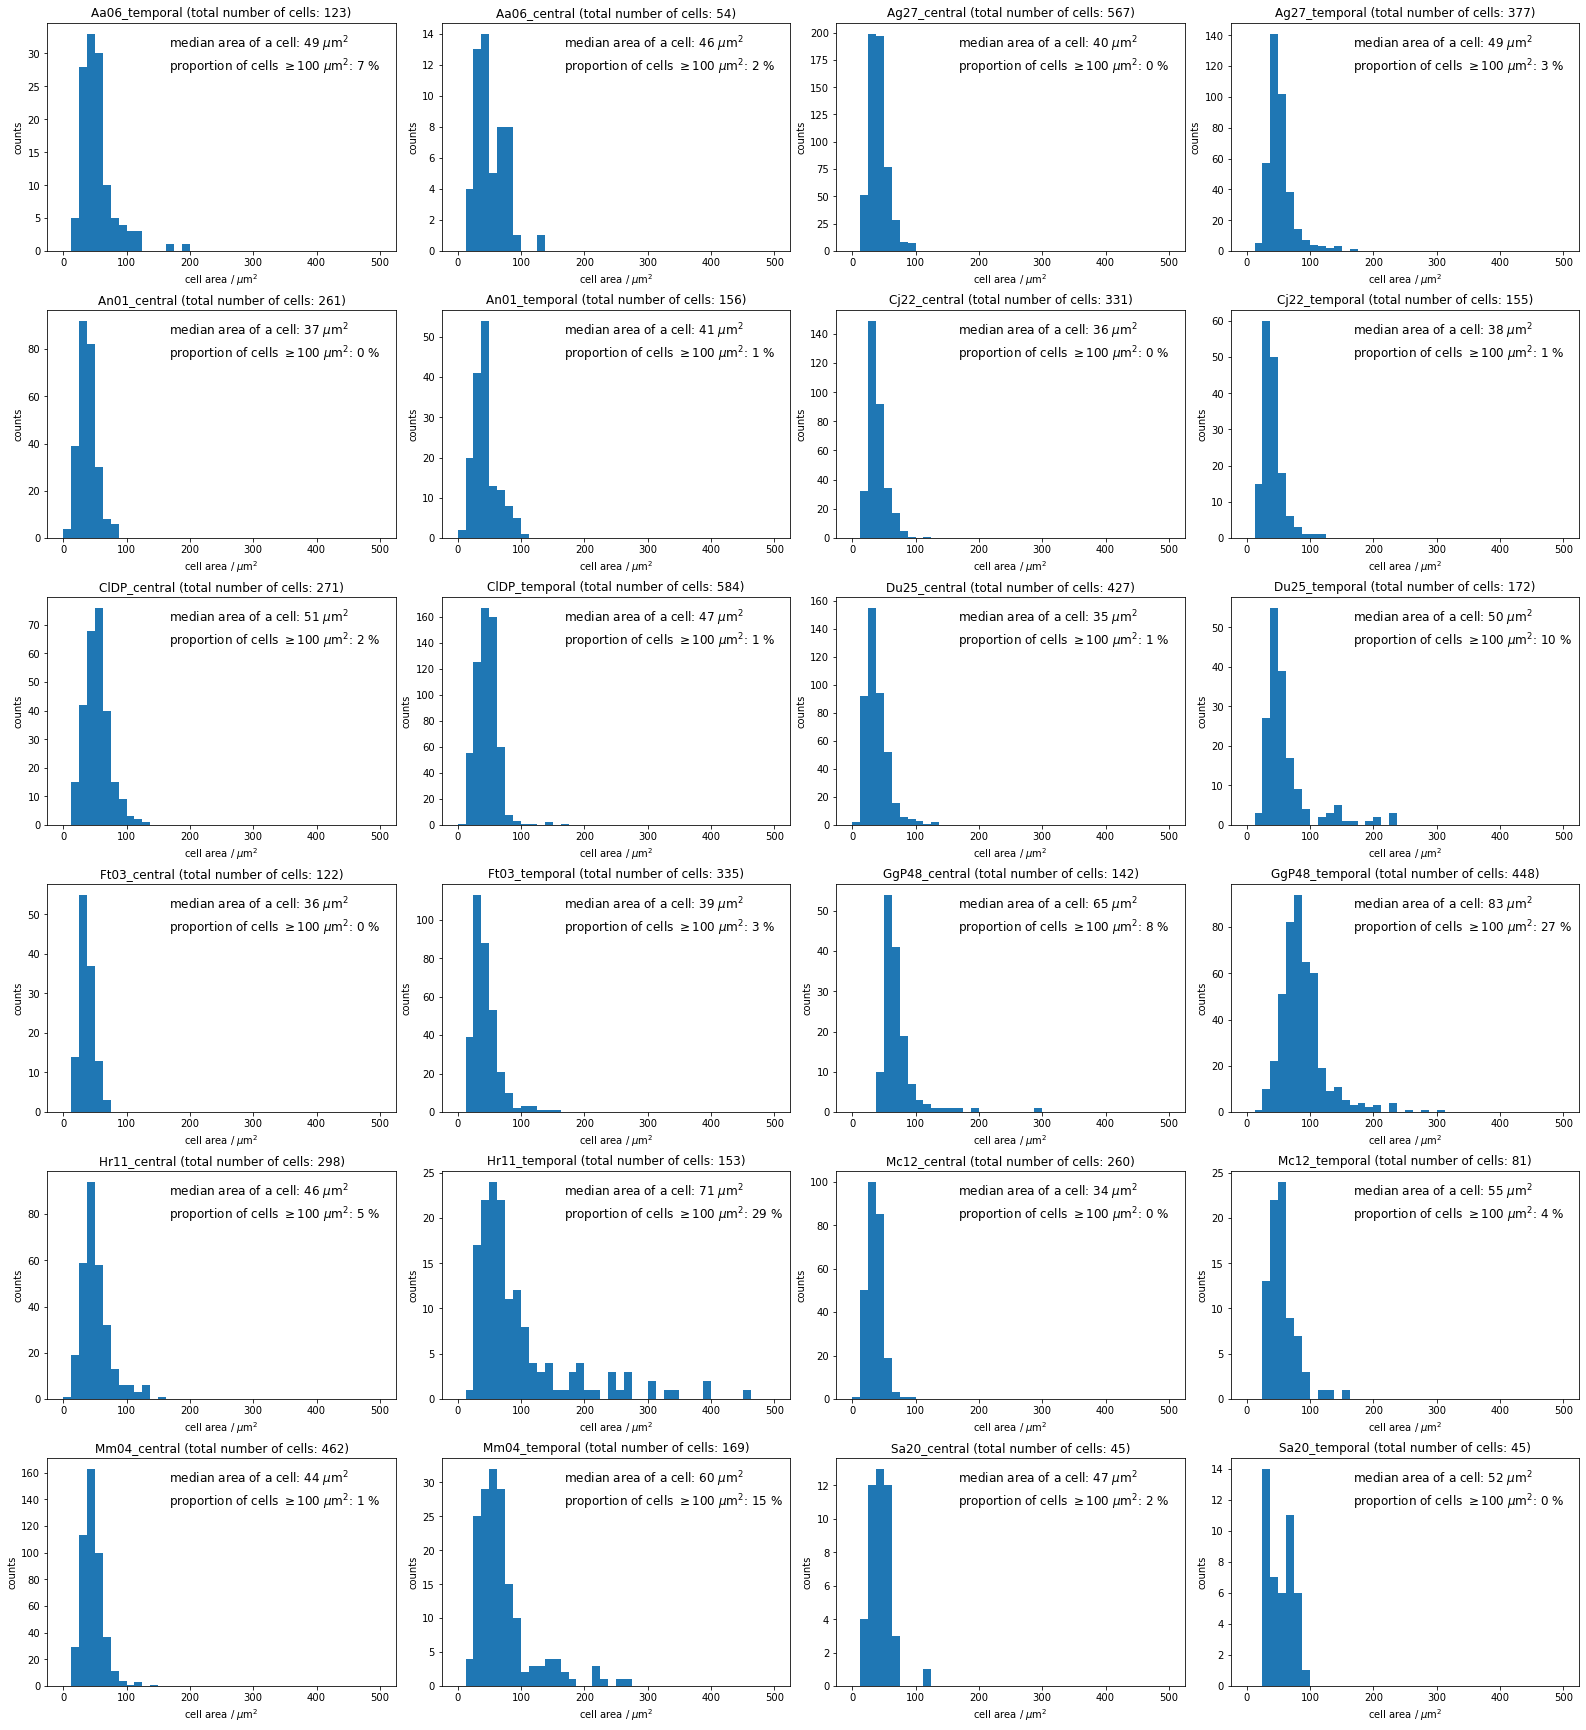

In [5]:
fig, axs = plt.subplots(nrows=6, ncols=4, figsize=(22, 24))
spc = [
    (0,0), (0,1), (0,2), (0,3),
    (1,0), (1,1), (1,2), (1,3),
    (2,0), (2,1), (2,2), (2,3),
    (3,0), (3,1), (3,2), (3,3),
    (4,0), (4,1), (4,2), (4,3),
    (5,0), (5,1), (5,2), (5,3),
]
idx = -1
for k, areas in area_dict.items():
    idx = idx + 1
    print(k, ("min area :", np.min(areas), "max area :", np.max(areas))) 
    #print("median :", np.median(areas))
    percent_gt_thr = round(len([True for i in areas if i > 100]) / len(areas) * 100) # ratio of cells larger than 100 microns
    h = axs[spc[idx][0], spc[idx][1]].hist(areas, 40, range=(0, 500), density=False)
    #axs[spc[idx][0], spc[idx][1]].vlines(np.median(areas), 0, np.max(h[0])+2, color='black')
    axs[spc[idx][0], spc[idx][1]].set_ylabel('counts')
    axs[spc[idx][0], spc[idx][1]].set_xlabel(r'cell area / $\mu$m$^2$')
    #axs[spc[idx][0], spc[idx][1]].set_title(re.split('/|\.|_Roi', roiset_file)[1] + ' (total number of cells: ' + str(len(areas)) + ')')
    axs[spc[idx][0], spc[idx][1]].set_title(k + ' (total number of cells: ' + str(len(areas)) + ')')
    textstr = '\n'.join((
    f'median area of a cell: {np.median(areas):.0f} $\mu$m$^2$',
    f'proportion of cells $\geq 100\ \mu$m$^2$: {percent_gt_thr:.0f} %'
    ))
    axs[spc[idx][0], spc[idx][1]].text(0.35, 0.95, textstr, transform=axs[spc[idx][0], spc[idx][1]].transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left')
    plt.tight_layout(pad=.6)
    fig.savefig(os.path.join(path2retines, "plots", "cell_area_distribution_all_species.png"), facecolor='white')
    

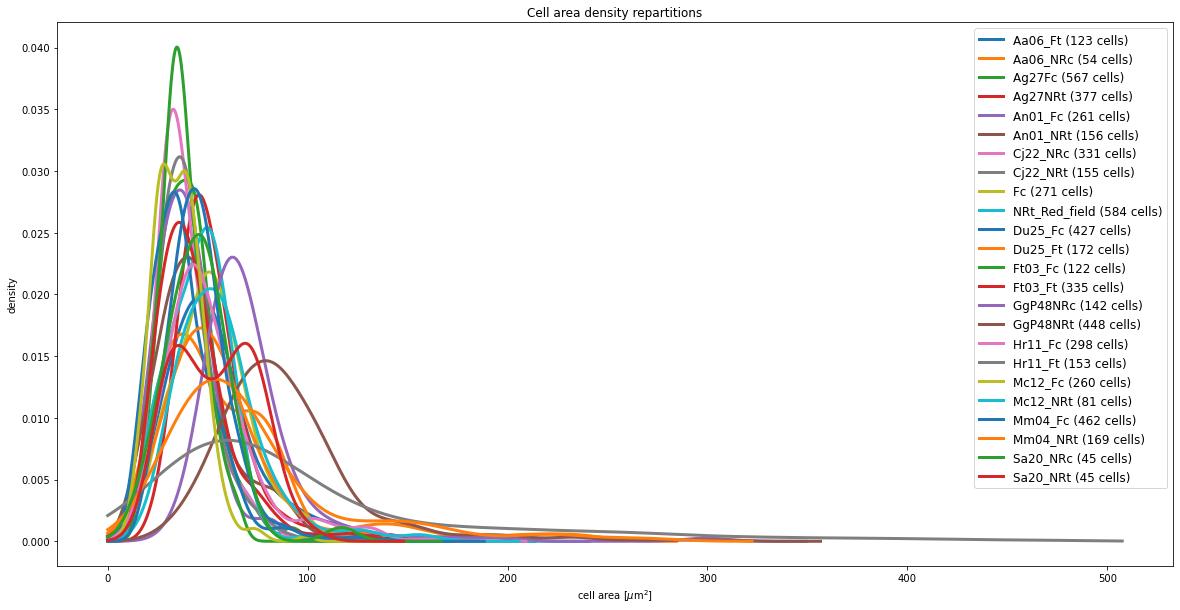

In [6]:
from scipy.stats import kde
fig, ax = plt.subplots(figsize=(20, 10))
#fig = plt.figure(figsize=(10, 5))
for idx in roifiles.keys():
    roiset_file = roifiles[idx]
    #print("microns/px ratio : ", ratio[idx])
    path2roiset = os.path.join(path2retines, roiset_file)
    # import rois from zip file:
    rois = read_roi_zip(path2roiset)
    # convert rois to shapely.Polygon objects:
    polygons_list = []
    for r in rois:
        poly = (r, contour2polygon(np.column_stack((rois[r]['x'], rois[r]['y']))))
        polygons_list.append(poly)
    # sort in-place polygons from  largest to smallest: 
    #polygons_list.sort(key=lambda x: x[1].area, reverse=True)
    areas = [polygons_list[i][1].area * ratio[idx] ** 2 for i in range(len(polygons_list))]
    #print(("min area :", np.min(areas), "max area :", np.max(areas))) 
    density = kde.gaussian_kde(areas)
    x = np.linspace(0,np.max(areas)+50,300)
    y = density(x)
    ax.plot(x, y, linewidth=3, label=re.split('/|\.|_Roi', roiset_file)[1] + ' (' + str(len(areas)) + ' cells)')

ax.set_xlabel(r'cell area [$\mu$m$^2$]')
ax.set_ylabel('density')
ax.set_title("Cell area density repartitions")   
ax.legend(fontsize=12)
#fig.savefig(os.path.join(path2retines, "plots", "cell_area_density_all_species.png"), facecolor='white')


Check one pixel's area:

In [7]:
# pixels = read_roi_zip(os.path.join(path2retines, "Hr11/one_pixel.zip"))
# pixel_list = []
# for r in pixels:
#     poly = (r, contour2polygon(np.column_stack((pixels[r]['x'], pixels[r]['y']))))
#     print(poly[1].area)
#     pixel_list.append(poly)

In [8]:
# list(pixel_list[2][1].exterior.coords)


#### Violin plots:

In [9]:
# Define the orderong of specii on plot:
specii = (
    'Du25',
    'Hr11',
    'Ft03',
    'Aa06',
    'ClDP',
    'Mc12',
    'Ag27',
    'An01',
    'Mm04',
    'Sa20',
    'GgP48',
    'Cj22'
)
colors = {
    'Du25': '#1B24E0',
    'Hr11': '#1E72FA',
    'Ft03': '#32B8ED',
    'Aa06': '#F007F0', #'#FFC000',
    'ClDP': '#9E0300',
    'Mc12': '#B81800',
    'Ag27': '#D13400', 
    'An01': '#EB5905',
    'Mm04': '#FF7A01',
    'Sa20': '#297B52',
    'GgP48': '#1EB612',
    'Cj22': '#7EE67E'
}

In [10]:
# colors = {
#     'Aa06': '#FFC000',
#     'An01': '#8A0000',
#     'Cj22': '#7EE67E',
#     'Cl_PV_10W': '#FF0000',
#     'Ft03': '#00B0F0',
#     'GgP48': '#1EB612',
#     'Hr11': '#0000CC',
#     'Mc12': '#FF7C80',
#     'Mm04': '#C40000',
#     'Sa20': '#297B52',
#     'Du25': '#0080FF',
#     'Ag27': '#FF6666'
# }
#color_list = [colors[k] for k in colors if k in labels]
#color_list

In [11]:
def set_axis_style(ax, labels):
    ax.xaxis.set_tick_params(direction='out')
    ax.xaxis.set_ticks_position('bottom')
    ax.set_xticks(np.arange(1, len(labels) + 1))
    ax.set_xticklabels(labels)
    ax.set_xlim(0.25, len(labels) + 0.75)
    ax.set_xlabel('species')
    ax.set_ylabel(r'cell area distribution / $\mu$m$^2$')
    ax.set_ylim(ymin=0, ymax=460)
    ax.yaxis.set_major_locator(MultipleLocator(100))
    ax.yaxis.set_minor_locator(MultipleLocator(20))
    ax.yaxis.grid(which='major', linewidth=1.3)
    ax.yaxis.grid(which='minor', linewidth=0.7)
    ax.set_axisbelow(True)

def adjacent_values(vals, q1, q3):
    upper_adjacent_value = q3 + (q3 - q1) * 1.5
    upper_adjacent_value = np.clip(upper_adjacent_value, q3, vals[-1])
    lower_adjacent_value = q1 - (q3 - q1) * 1.5
    lower_adjacent_value = np.clip(lower_adjacent_value, vals[0], q1)
    return lower_adjacent_value, upper_adjacent_value

In [12]:
temporal = {}
central = {}
# split data into central and temporal
for k,v in area_dict.items():
    if "central" in k:
        central[k] = v
    else:
        temporal[k] = v
data_all = { # data for all subplots
    "temporal": temporal,
    "central": central
}

12
12


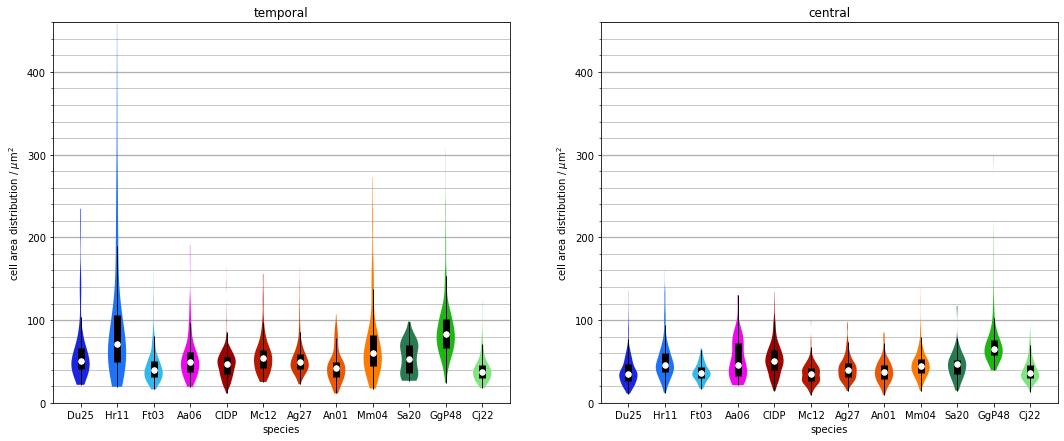

In [15]:
percent_greater_all = {}
medians_all = {}
mosaic_plot = True
idx = 0
if mosaic_plot:
    fig = plt.figure(figsize=(18,7))
for k, v in data_all.items(): # loop over (sub)plots   
    idx = idx + 1
    data = [] 
    labels = []
    percent_greater = {} # for later use
    medians_tmp = {} # for later use
    for species in specii:
        #print(species)
        kk = species + "_" + k
        vv = data_all[k][kk]
        data.append(sorted(vv))
        labels.append(species.split("_")[0]) # only useful for Cl_PV_10W
        medians_tmp[kk] = np.percentile(vv, 50)
        percent_greater[kk] = round(len([True for i in vv if i > 100]) / len(vv) * 100) # ratio of cells larger than 100 microns
    print(len(data))
    #print(central)
    #print(labels)
    ## Get some statistics:
    size = [len(x) for x in data]
    quartile1 = [np.percentile(data[index], 25) for index in range(len(data))]
    medians = [np.percentile(data[index], 50) for index in range(len(data))]
    medians_all[k] = medians_tmp
    percent_greater_all[k] = percent_greater
    quartile3 = [np.percentile(data[index], 75) for index in range(len(data))]
    whiskers = np.array([
        adjacent_values(sorted_array, q1, q3)
        for sorted_array, q1, q3 in zip(data, quartile1, quartile3)])
    whiskers_min, whiskers_max = whiskers[:, 0], whiskers[:, 1]
    
    if mosaic_plot:
        ax = plt.subplot(1, 2, idx)
        #plt.tight_layout(pad=1.0)
    else:
        fig = plt.figure(figsize=(7, 7))
        ax = plt.subplot(1, 1, 1)
        #plt.tight_layout(pad=.6)
    vp = plt.violinplot(data, showmeans=False, showmedians=False, showextrema=False)
    ax.set_title(k)
    inds = np.arange(1, len(data) + 1)
    ax.scatter(inds, medians, marker='o', color='white', s=30, zorder=3)
    ax.vlines(inds, whiskers_min, whiskers_max, color='k', linestyle='-', lw=1)
    #ax.scatter(np.ones((len(data[0]),1)), data[0], marker='.', color='black', s=30, zorder=3)
    ax.vlines(inds, quartile1, quartile3, color='k', linestyle='-', lw=7)
    set_axis_style(ax, labels)
    face_colors = [colors[k] for k in specii]
    # edge_colors = ['#000066', '#990000', '#003319']
    for i, pc in enumerate(vp['bodies']):
        pc.set_facecolor(face_colors[i])
        #pc.set_edgecolor(edge_colors[i])
        pc.set_alpha(1)
    if not mosaic_plot:
        plt.close(fig) # avoid displaying plots in interactive mode
        fig.savefig(os.path.join(path2retines, "plots", "RGC_distribution_" + k + ".png"), facecolor='white')
if mosaic_plot:
    fig.savefig(os.path.join(path2retines, "plots", "RGC_distribution_all.png"), facecolor='white')
    plt.show()

In [14]:
print(percent_greater_all)
print(medians_all)

{'temporal': {'Du25_temporal': 10, 'Hr11_temporal': 29, 'Ft03_temporal': 3, 'Aa06_temporal': 7, 'ClDP_temporal': 1, 'Mc12_temporal': 4, 'Ag27_temporal': 3, 'An01_temporal': 1, 'Mm04_temporal': 15, 'Sa20_temporal': 0, 'GgP48_temporal': 27, 'Cj22_temporal': 1}, 'central': {'Du25_central': 1, 'Hr11_central': 5, 'Ft03_central': 0, 'Aa06_central': 2, 'ClDP_central': 2, 'Mc12_central': 0, 'Ag27_central': 0, 'An01_central': 0, 'Mm04_central': 1, 'Sa20_central': 2, 'GgP48_central': 8, 'Cj22_central': 0}}
{'temporal': {'Du25_temporal': 50.33973452244105, 'Hr11_temporal': 70.94747867860788, 'Ft03_temporal': 39.41437153677713, 'Aa06_temporal': 48.81794882516126, 'ClDP_temporal': 46.592346867106635, 'Mc12_temporal': 54.693880614074004, 'Ag27_temporal': 48.81840461370172, 'An01_temporal': 41.489271998506695, 'Mm04_temporal': 60.46170739279714, 'Sa20_temporal': 52.479648817802506, 'GgP48_temporal': 82.990270350878, 'Cj22_temporal': 37.65111575638598}, 'central': {'Du25_central': 35.096366193262824, 